# This notebook shows how to fit a resonator with Kerr nonlinearity in the reflection configuration.

## Fit the model to the data using a KerrReflectionFitter.

Here, we know the standard error of each data point because we added the noise. If no errors are given, the fitting assumes equal errors for each point and thus equal weights, so errors are not generally necessary unless they vary between points.

In [1]:
import pandas as pd
from __future__ import division, absolute_import, print_function
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/ms3_2025-02-19/MS3_critical_coupling_-20dBm_10kHzbdw.csv")
df

resonator = reflection.KerrReflectionFitter(frequency=f, data=s21n, choose=choose)
print(resonator.result.fit_report())  # result is a lmfit.model.ModelResult object

ModuleNotFoundError: No module named 'pandas'

## Plot the data

Use the `see.py` fitting module to plot the data, model, and resonance.

/var/folders/ms/v50d13217mz8zv9r78914mq40000gn/T/ipykernel_13417/808775078.py:6: UserWarning: Mismatched number of handles and labels: len(handles) = 5 len(labels) = 3
  ax_raw.legend(handles=ax_raw.lines, labels=('data', 'fit', 'resonance'), fontsize='xx-small');


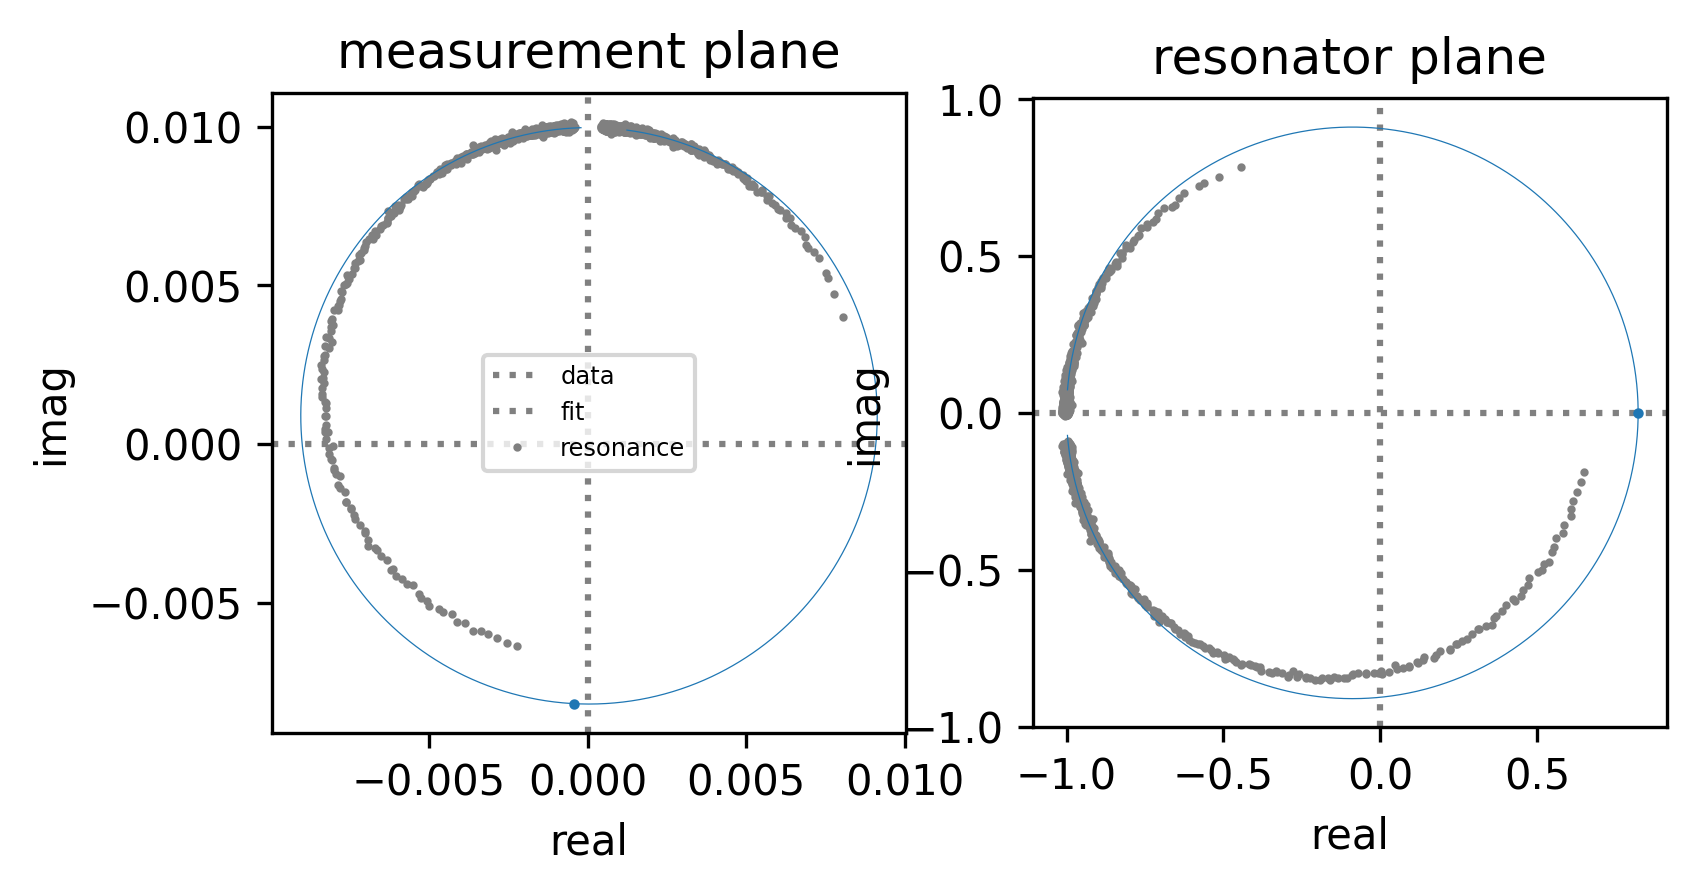

In [19]:
fig, (ax_raw, ax_norm) = plt.subplots(1, 2, figsize=(6, 3), dpi=300)  # Adjust these values for your plot settings
ax_raw.set_title('measurement plane')
ax_norm.set_title('resonator plane')
see.real_and_imaginary(resonator=resonator, axes=ax_raw, normalize=False)
see.real_and_imaginary(resonator=resonator, axes=ax_norm, normalize=True)
ax_raw.legend(handles=ax_raw.lines, labels=('data', 'fit', 'resonance'), fontsize='xx-small');

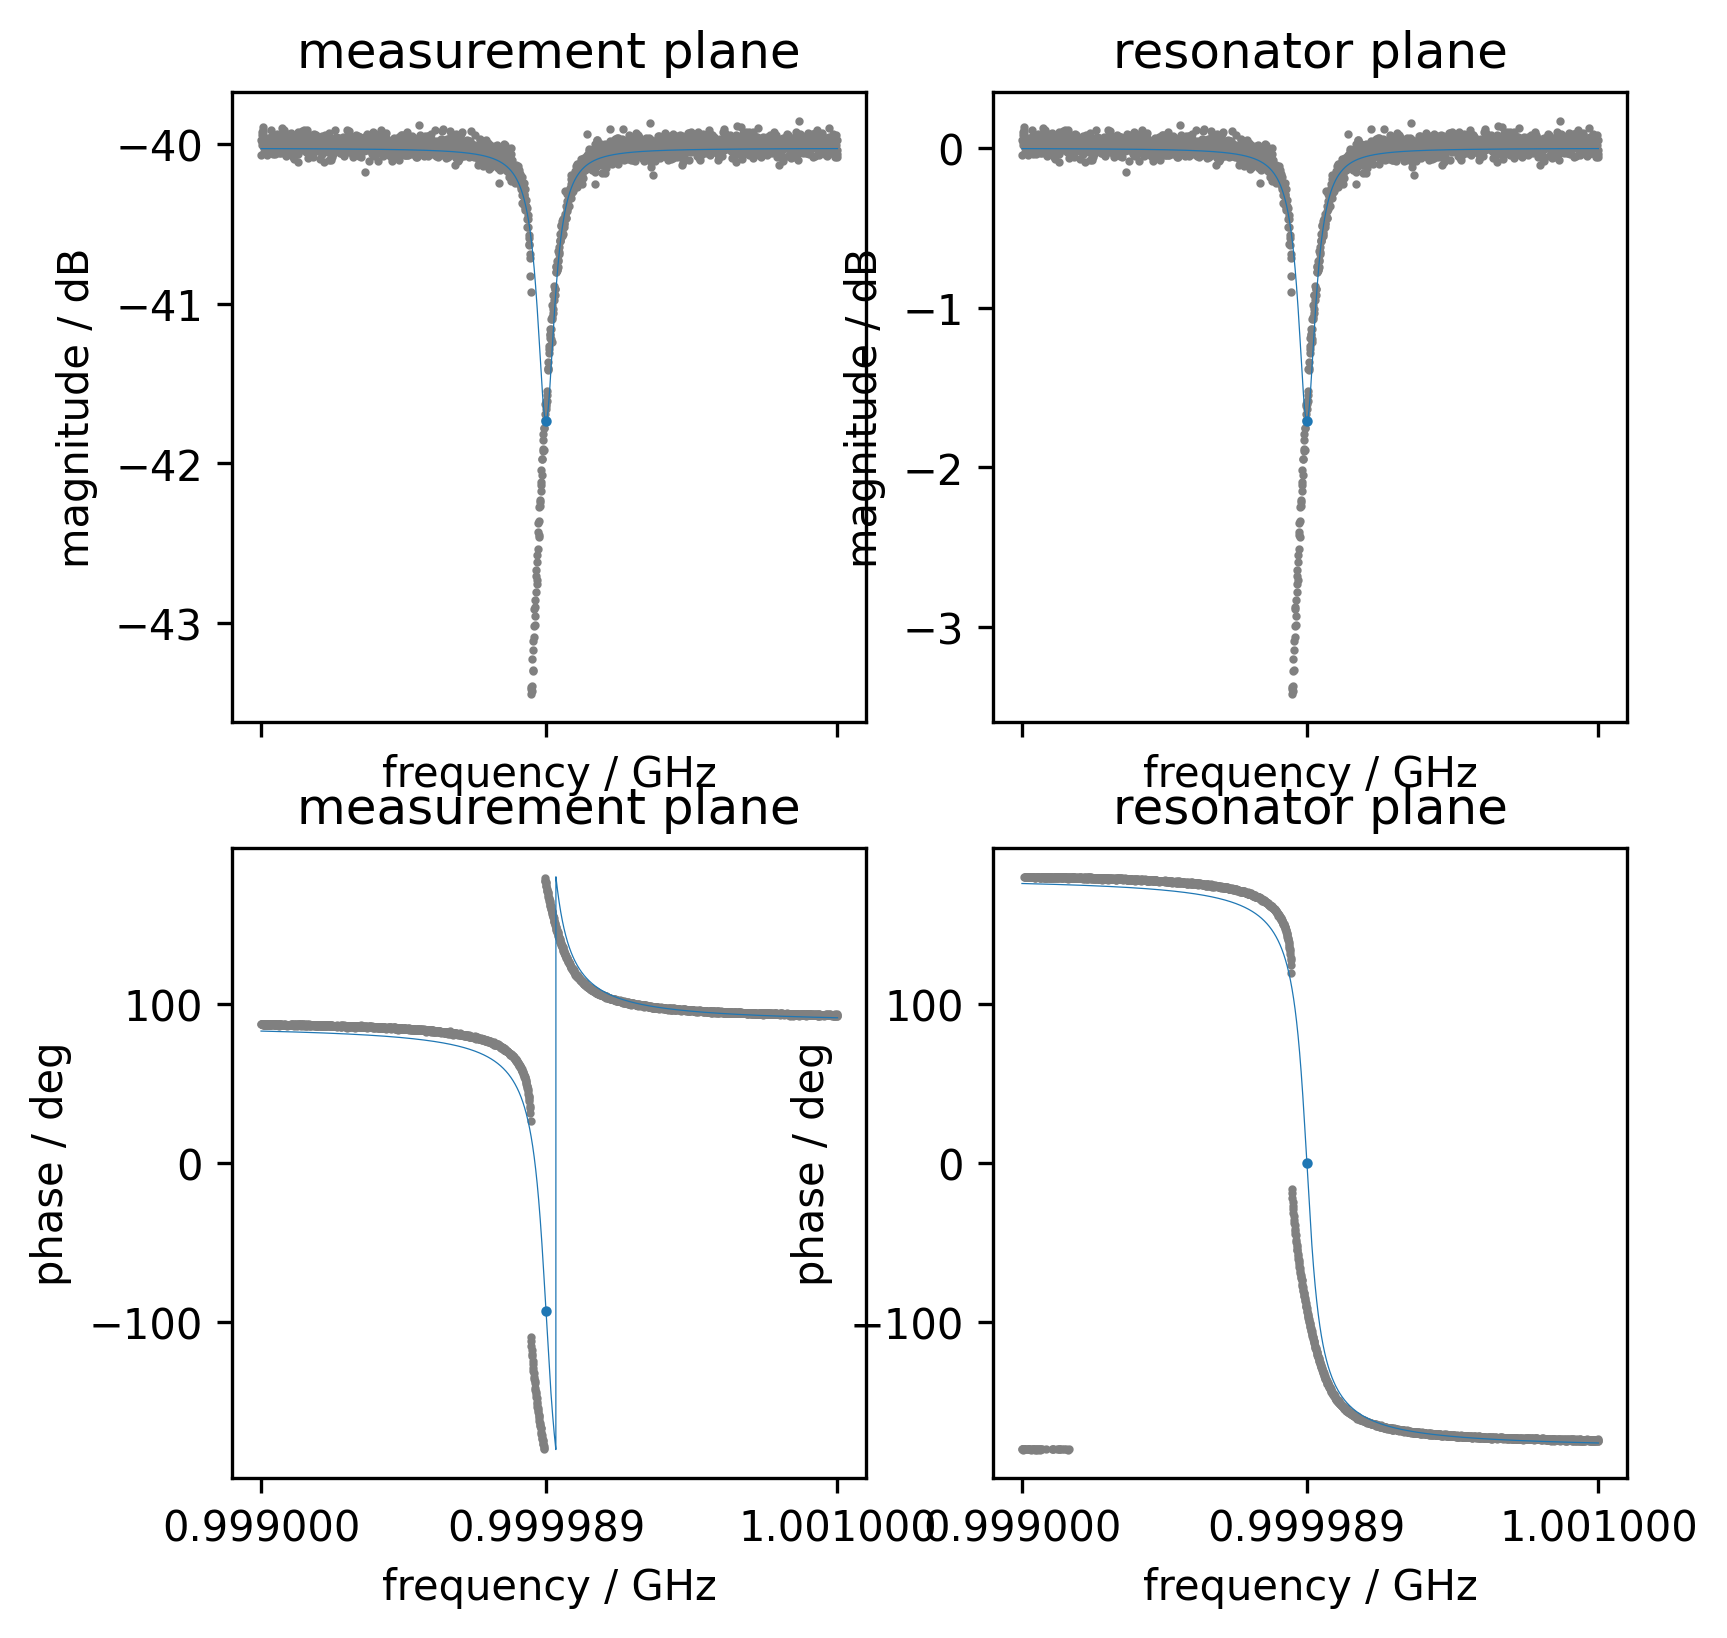

In [20]:
fig, axes = plt.subplots(2, 2, sharex='all', figsize=(6, 6), dpi=300)  # Adjust these values for your plot settings
ax_raw_mag, ax_norm_mag, ax_raw_phase, ax_norm_phase = axes.flatten()
ax_raw_mag.set_title('measurement plane')
ax_norm_mag.set_title('resonator plane')
ax_raw_phase.set_title('measurement plane')
ax_norm_phase.set_title('resonator plane')
see.magnitude_vs_frequency(resonator=resonator, axes=ax_raw_mag, normalize=False, frequency_scale=1e-9)
see.magnitude_vs_frequency(resonator=resonator, axes=ax_norm_mag, normalize=True, frequency_scale=1e-9)
see.phase_vs_frequency(resonator=resonator, axes=ax_raw_phase, normalize=False, frequency_scale=1e-9)
see.phase_vs_frequency(resonator=resonator, axes=ax_norm_phase, normalize=True, frequency_scale=1e-9);

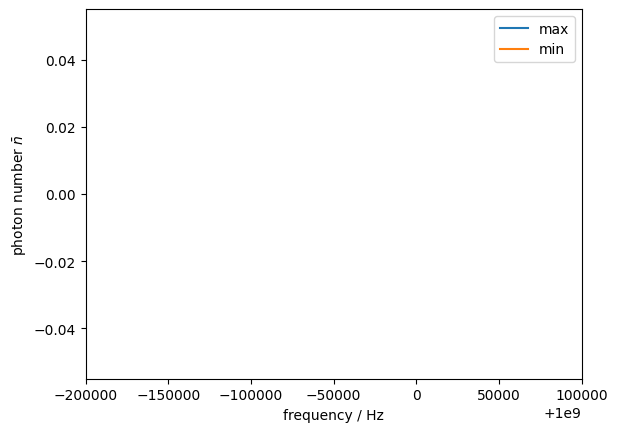

In [21]:
fig, ax = plt.subplots()
ax.set_xlabel('frequency / Hz')
ax.set_ylabel(r'photon number $\bar{n}$')
ax.plot(f, resonator.photon_number(input_frequency=f, input_rate=resonator.f_r), label='max')
# Calculate the photon number using another root-finding function that selects the minimum Kerr detuning.
# Since the Kerr coefficient is negative here the Kerr detuning is also negative, so choosing the minimum
# (most negative) detuning corresponds to choosing the maximum photon number.
ax.plot(f, resonator.photon_number(input_frequency=f, input_rate=resonator.f_r, choose=np.min), label='min')
ax.legend()
ax.set_xlim(f_r - 2e5, f_r + 1e5);

array([ inf, -inf,  inf, ...,  inf,  inf, -inf], shape=(2001,))